# Cognifyz Machine Learning Internship

## Task 1 — Predict Restaurant Ratings

### Objective

Build a machine learning regression model to predict the
aggregate rating of a restaurant based on relevant restaurant
features.

### Approach

1. Load the cleaned rated-restaurant dataset.
2. Define the target variable.
3. Select relevant predictive features.
4. Perform feature engineering.
5. Split the dataset into training and testing sets.
6. Build a preprocessing pipeline.
7. Prepare the data for regression models.

In [111]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [112]:
df = pd.read_csv("../outputs/results/rated_restaurants.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7403, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [113]:
print("Minimum rating:", df["Aggregate rating"].min())
print("Maximum rating:", df["Aggregate rating"].max())
print("Zero ratings:", (df["Aggregate rating"] == 0).sum())

Minimum rating: 1.8
Maximum rating: 4.9
Zero ratings: 0


In [114]:
y = df["Aggregate rating"]

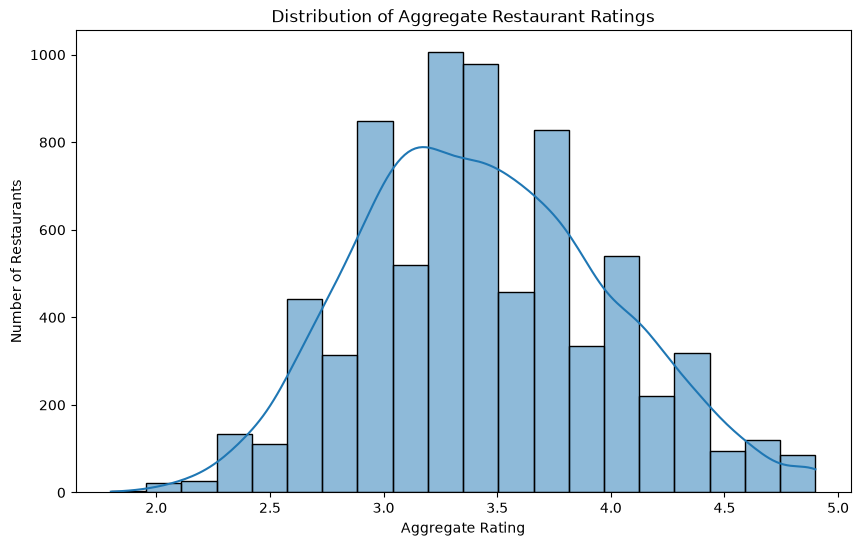

In [115]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Aggregate rating",
    bins=20,
    kde=True
)

plt.title("Distribution of Aggregate Restaurant Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.savefig(
    "../outputs/figures/task1_rating_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [116]:
df["Primary Cuisine"] = (
    df["Cuisines"]
    .fillna("Unknown")
    .str.split(",")
    .str[0]
    .str.strip()
)

In [117]:
df[
    ["Cuisines", "Primary Cuisine"]
].head(20)

,Cuisines,Primary Cuisine
0,"French, Japanese, Desserts",French
1,Japanese,Japanese
2,"Seafood, Asian, Filipino, Indian",Seafood
3,"Japanese, Sushi",Japanese
4,"Japanese, Korean",Japanese
5,Chinese,Chinese
6,"Asian, European",Asian
7,"Seafood, Filipino, Asian, European",Seafood
8,"European, Asian, Indian",European
9,Filipino,Filipino


In [118]:
print(
    "Unique primary cuisines:",
    df["Primary Cuisine"].nunique()
)

Unique primary cuisines: 119


In [119]:
features = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Latitude",
    "Longitude",
    "Country Code",
    "City",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Primary Cuisine"
]

target = "Aggregate rating"

In [120]:
X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7403, 11)
y shape: (7403,)


In [121]:
X.head()

,Average Cost for two,Price range,Votes,Latitude,Longitude,Country Code,City,Has Table booking,Has Online delivery,Is delivering now,Primary Cuisine
0,1100,3,314,14.565443,121.027535,162,Makati City,Yes,No,No,French
1,1200,3,591,14.553708,121.014101,162,Makati City,Yes,No,No,Japanese
2,4000,4,270,14.581404,121.056831,162,Mandaluyong City,Yes,No,No,Seafood
3,1500,4,365,14.585318,121.056475,162,Mandaluyong City,No,No,No,Japanese
4,1500,4,229,14.584450,121.057508,162,Mandaluyong City,Yes,No,No,Japanese


In [122]:
y.head()

0    4.8
1    4.5
2    4.4
3    4.9
4    4.8
Name: Aggregate rating, dtype: float64

In [123]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7403 entries, 0 to 7402
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Average Cost for two  7403 non-null   int64  
 1   Price range           7403 non-null   int64  
 2   Votes                 7403 non-null   int64  
 3   Latitude              7403 non-null   float64
 4   Longitude             7403 non-null   float64
 5   Country Code          7403 non-null   int64  
 6   City                  7403 non-null   str    
 7   Has Table booking     7403 non-null   str    
 8   Has Online delivery   7403 non-null   str    
 9   Is delivering now     7403 non-null   str    
 10  Primary Cuisine       7403 non-null   object 
dtypes: float64(2), int64(4), object(1), str(4)
memory usage: 636.3+ KB


In [124]:
X.isnull().sum()

Average Cost for two    0
Price range             0
Votes                   0
Latitude                0
Longitude               0
Country Code            0
City                    0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Primary Cuisine         0
dtype: int64

In [125]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [126]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5922
Testing samples: 1481


In [127]:
numeric_features = [
    "Average Cost for two",
    "Price range",
    "Votes",
    "Latitude",
    "Longitude"
]

categorical_features = [
    "Country Code",
    "City",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Primary Cuisine"
]

In [128]:
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Average Cost for two', 'Price range', 'Votes', 'Latitude', 'Longitude']
Categorical features: ['Country Code', 'City', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Primary Cuisine']


In [129]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [130]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [131]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [132]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [133]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5922, 11)
Processed training shape: (5922, 278)
Original testing shape: (1481, 11)
Processed testing shape: (1481, 278)


In [134]:
preprocessor.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 65142 stored elements and shape (5922, 278)>

In [135]:
preprocessor.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16283 stored elements and shape (1481, 278)>

In [136]:
preprocessor.fit_transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16291 stored elements and shape (1481, 193)>

In [137]:
from sklearn.linear_model import LinearRegression

In [138]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [139]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Average Cost for two','Price range','Votes',...,'Has Online delivery', 'Is delivering now','Primary Cuisine']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [140]:
y_pred = linear_model.predict(X_test)

In [141]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [142]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Linear Regression Baseline")
print("---------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Baseline
---------------------------
MAE : 0.30360507099203937
MSE : 0.1506301876872599
RMSE: 0.3881110507152043
R²  : 0.5129657875377254


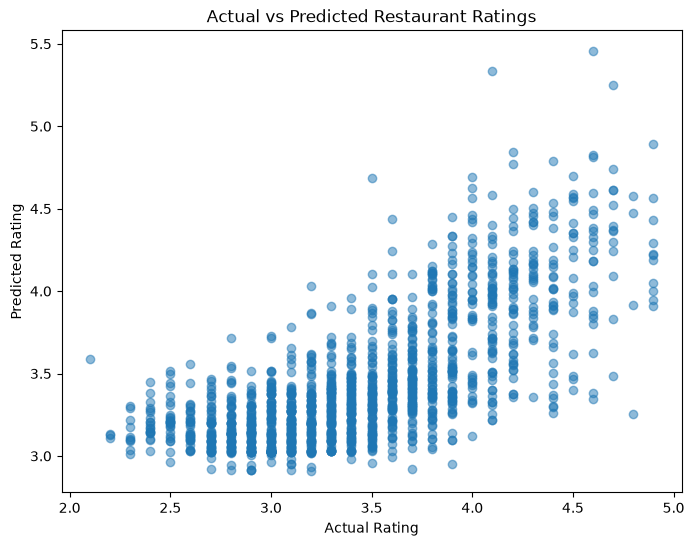

In [143]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Restaurant Ratings")

plt.savefig(
    "../outputs/figures/task1_actual_vs_predicted_linear.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

# Baseline Model — Linear Regression

A Linear Regression model was selected as the baseline regression model.

The preprocessing pipeline performs:

- Median imputation for numerical missing values
- Standardization of numerical features
- Most-frequent imputation for categorical variables
- One-hot encoding of categorical variables

The model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² score

# Model Training

In [144]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [145]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [146]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42,
                max_depth=10
            )
        )
    ]
)

In [147]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                max_depth=15
            )
        )
    ]
)

In [148]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Average Cost for two','Price range','Votes',...,'Has Online delivery', 'Is delivering now','Primary Cuisine']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [149]:
linear_pred = linear_model.predict(X_test)

In [150]:
decision_tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Average Cost for two','Price range','Votes',...,'Has Online delivery', 'Is delivering now','Primary Cuisine']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [151]:
decision_tree_pred = decision_tree_model.predict(X_test)

In [152]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Average Cost for two','Price range','Votes',...,'Has Online delivery', 'Is delivering now','Primary Cuisine']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automaticall

In [153]:
random_forest_pred = random_forest_model.predict(X_test)

In [154]:
def evaluate_regression_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    }

In [155]:
results = []

results.append(
    evaluate_regression_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_regression_model(
        "Decision Tree",
        y_test,
        decision_tree_pred
    )
)

results.append(
    evaluate_regression_model(
        "Random Forest",
        y_test,
        random_forest_pred
    )
)

In [156]:
results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.303605,0.150630,0.388111,0.512966
1,Decision Tree,0.274721,0.144348,0.379932,0.533277
2,Random Forest,0.242455,0.107555,0.327956,0.652240


In [157]:
results_df = results_df.round(4)

results_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.3036,0.1506,0.3881,0.5130
1,Decision Tree,0.2747,0.1443,0.3799,0.5333
2,Random Forest,0.2425,0.1076,0.3280,0.6522


In [158]:
results_df.to_csv(
    "../outputs/results/task1_model_comparison.csv",
    index=False
)

In [159]:
best_mae_model = results_df.loc[
    results_df["MAE"].idxmin(),
    "Model"
]

print("Best model based on MAE:", best_mae_model)

Best model based on MAE: Random Forest


In [160]:
best_r2_model = results_df.loc[
    results_df["R²"].idxmax(),
    "Model"
]

print("Best model based on R²:", best_r2_model)

Best model based on R²: Random Forest


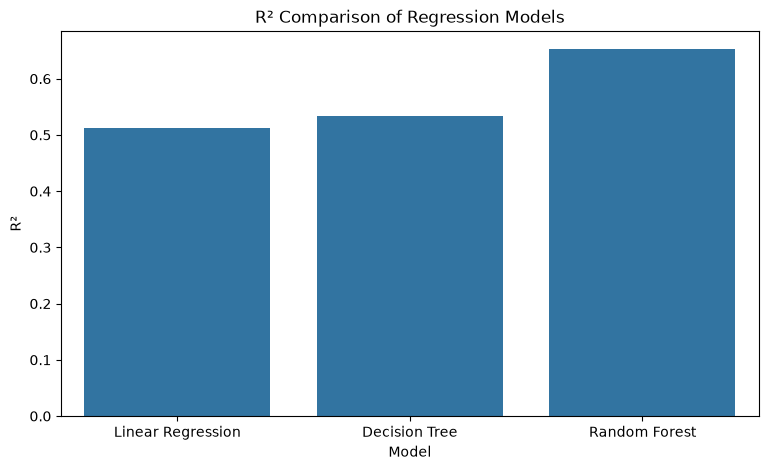

In [161]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R²"
)

plt.title("R² Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("R²")

plt.savefig(
    "../outputs/figures/task1_model_r2_comparison.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

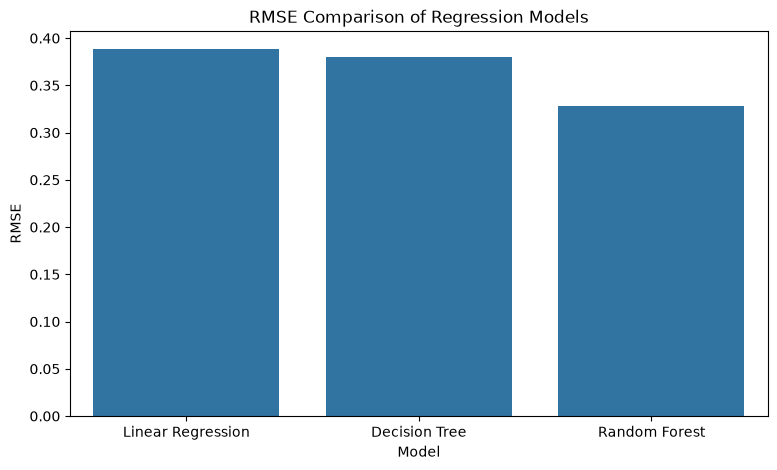

In [162]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison of Regression Models")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.savefig(
    "../outputs/figures/task1_model_rmse_comparison.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [163]:
predictions = {
    "Linear Regression": linear_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
}

In [164]:
best_model_name = results_df.loc[
    results_df["R²"].idxmax(),
    "Model"
]

best_predictions = predictions[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


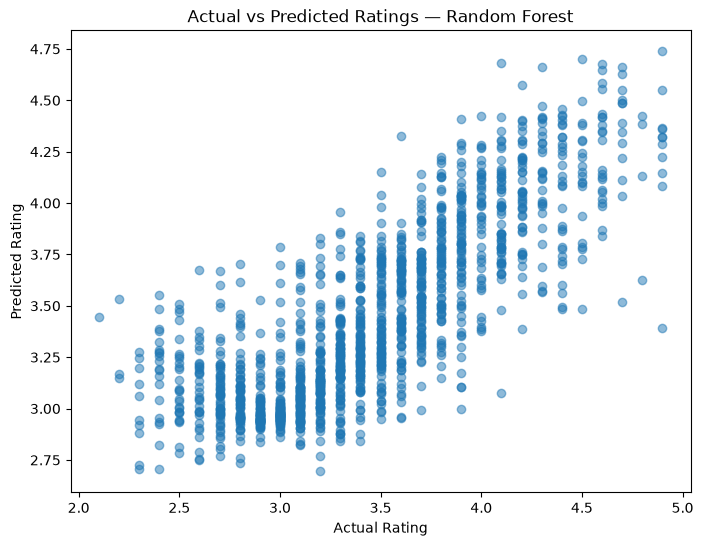

In [165]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title(
    f"Actual vs Predicted Ratings — {best_model_name}"
)

plt.savefig(
    "../outputs/figures/task1_best_model_actual_vs_predicted.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

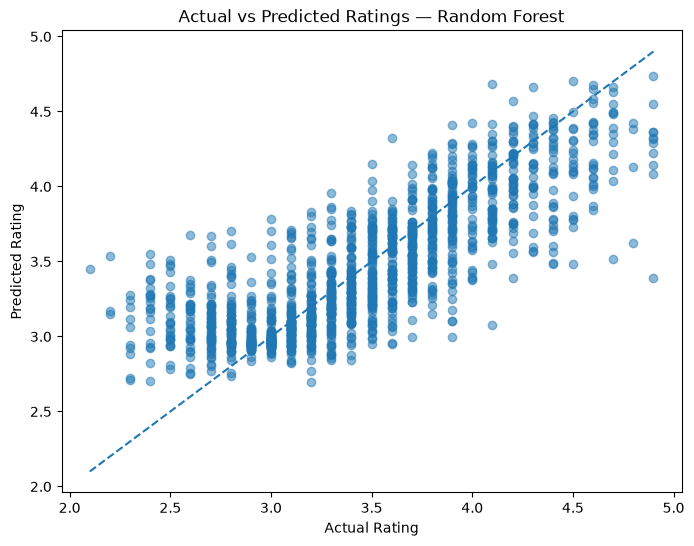

In [166]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

min_rating = min(y_test.min(), best_predictions.min())
max_rating = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_rating, max_rating],
    [min_rating, max_rating],
    linestyle="--"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title(
    f"Actual vs Predicted Ratings — {best_model_name}"
)

plt.savefig(
    "../outputs/figures/task1_best_model_actual_vs_predicted.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [167]:
prediction_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

prediction_analysis["Error"] = (
    prediction_analysis["Actual"]
    - prediction_analysis["Predicted"]
)

prediction_analysis["Absolute Error"] = (
    prediction_analysis["Error"].abs()
)

prediction_analysis.head()

,Actual,Predicted,Error,Absolute Error
0,2.9,2.911384,-0.011384,0.011384
1,3.9,3.250124,0.649876,0.649876
2,2.8,2.758924,0.041076,0.041076
3,2.3,2.883308,-0.583308,0.583308
4,3.2,3.139849,0.060151,0.060151


In [168]:
prediction_analysis.sort_values(
    "Absolute Error",
    ascending=False
).head(10)

,Actual,Predicted,Error,Absolute Error
918,4.9,3.390614,1.509386,1.509386
838,2.1,3.447882,-1.347882,1.347882
1134,2.2,3.535144,-1.335144,1.335144
1368,4.7,3.516585,1.183415,1.183415
660,4.8,3.625982,1.174018,1.174018
917,2.4,3.551074,-1.151074,1.151074
25,2.4,3.485498,-1.085498,1.085498
1101,2.6,3.675179,-1.075179,1.075179
897,4.1,3.077315,1.022685,1.022685
708,4.5,3.484258,1.015742,1.015742


In [169]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_model = random_forest_model.named_steps["model"]

In [170]:
feature_names = rf_preprocessor.get_feature_names_out()

In [171]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

In [172]:
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

In [173]:
feature_importance.head(20)

,Feature,Importance
2,num__Votes,0.524111
4,num__Longitude,0.128875
3,num__Latitude,0.106515
0,num__Average Cost for two,0.054927
5,cat__Country Code_1,0.042556
238,cat__Primary Cuisine_North Indian,0.015118
164,cat__Primary Cuisine_American,0.008743
188,cat__Primary Cuisine_Chinese,0.008000
7,cat__Country Code_30,0.007243
1,num__Price range,0.007050


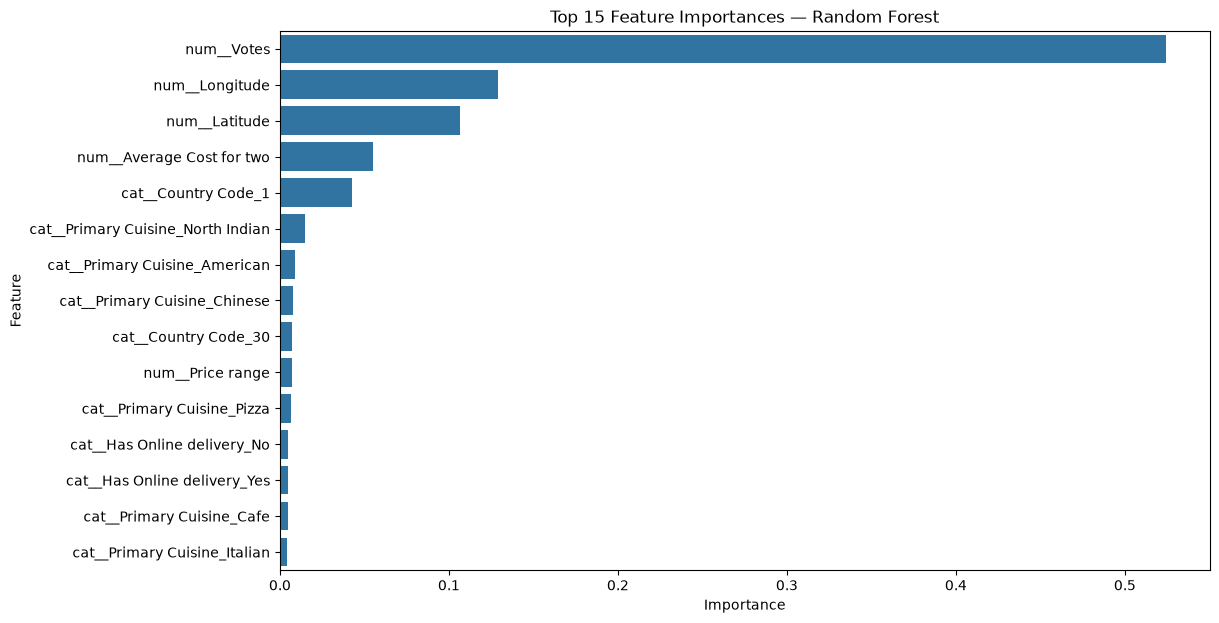

In [174]:
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig(
    "../outputs/figures/task1_feature_importance.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [175]:
feature_importance.to_csv(
    "../outputs/results/task1_feature_importance.csv",
    index=False
)

# Task 1 — Model Comparison

Three regression models were evaluated:

1. Linear Regression
2. Decision Tree Regression
3. Random Forest Regression

The models were evaluated using Mean Absolute Error (MAE),
Mean Squared Error (MSE), Root Mean Squared Error (RMSE),
and R² score.

Lower values of MAE, MSE, and RMSE indicate lower prediction
error, while a higher R² indicates better explanatory performance.

The best-performing model was selected based on the evaluation
results obtained on the held-out test set.

Feature importance from the tree-based model was also analyzed
to identify features that contributed most strongly to model
predictions.

In [176]:
# Day 6 — Model Interpretation and Task 1 Finalization

In [177]:
results_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.3036,0.1506,0.3881,0.5130
1,Decision Tree,0.2747,0.1443,0.3799,0.5333
2,Random Forest,0.2425,0.1076,0.3280,0.6522


In [178]:
best_mae_model = results_df.loc[
    results_df["MAE"].idxmin()
]

best_mae_model

Model    Random Forest
MAE             0.2425
MSE             0.1076
RMSE             0.328
R²              0.6522
Name: 2, dtype: object

In [179]:
best_r2_model = results_df.loc[
    results_df["R²"].idxmax()
]

best_r2_model

Model    Random Forest
MAE             0.2425
MSE             0.1076
RMSE             0.328
R²              0.6522
Name: 2, dtype: object

In [180]:
print("Best model based on MAE:")
print(best_mae_model)

print("\nBest model based on R²:")
print(best_r2_model)

Best model based on MAE:
Model    Random Forest
MAE             0.2425
MSE             0.1076
RMSE             0.328
R²              0.6522
Name: 2, dtype: object

Best model based on R²:
Model    Random Forest
MAE             0.2425
MSE             0.1076
RMSE             0.328
R²              0.6522
Name: 2, dtype: object


### Model Selection

The models were compared using MAE, MSE, RMSE, and R².

The final model was selected by considering both prediction error
and explanatory performance on the held-out test dataset.

In [181]:
final_results = results_df.copy()

final_results = final_results.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

final_results.round(4)

,Model,MAE,MSE,RMSE,R²
0,Random Forest,0.2425,0.1076,0.3280,0.6522
1,Decision Tree,0.2747,0.1443,0.3799,0.5333
2,Linear Regression,0.3036,0.1506,0.3881,0.5130


In [182]:
final_results.to_csv(
    "../outputs/results/task1_final_model_comparison.csv",
    index=False
)

In [183]:
best_model_name = results_df.loc[
    results_df["R²"].idxmax(),
    "Model"
]

baseline_r2 = results_df.loc[
    results_df["Model"] == "Linear Regression",
    "R²"
].iloc[0]

best_r2 = results_df.loc[
    results_df["Model"] == best_model_name,
    "R²"
].iloc[0]

r2_improvement = best_r2 - baseline_r2

print("Best model:", best_model_name)
print("Baseline R²:", round(baseline_r2, 4))
print("Best model R²:", round(best_r2, 4))
print("R² improvement:", round(r2_improvement, 4))

Best model: Random Forest
Baseline R²: 0.513
Best model R²: 0.6522
R² improvement: 0.1392


In [184]:
predictions = {
    "Linear Regression": linear_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
}

best_model_name = results_df.loc[
    results_df["R²"].idxmax(),
    "Model"
]

best_predictions = predictions[best_model_name]

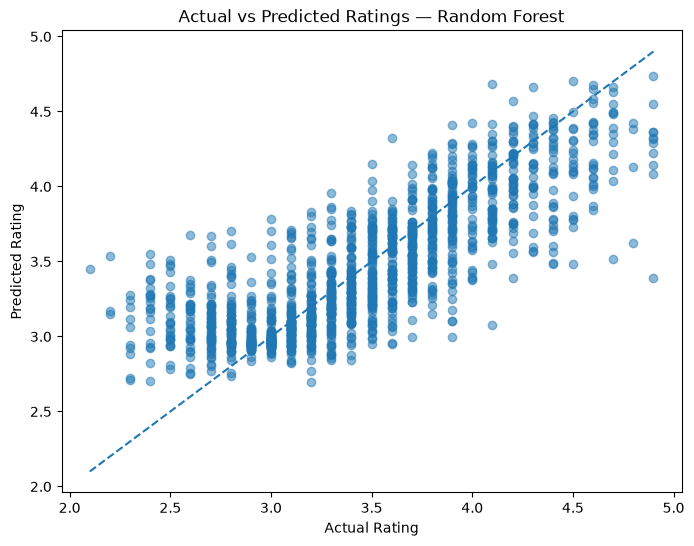

In [185]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title(
    f"Actual vs Predicted Ratings — {best_model_name}"
)

plt.savefig(
    "../outputs/figures/task1_final_actual_vs_predicted.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [186]:
prediction_analysis = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": best_predictions
})

prediction_analysis["Error"] = (
    prediction_analysis["Actual Rating"]
    - prediction_analysis["Predicted Rating"]
)

prediction_analysis["Absolute Error"] = (
    prediction_analysis["Error"].abs()
)

prediction_analysis.head()

,Actual Rating,Predicted Rating,Error,Absolute Error
0,2.9,2.911384,-0.011384,0.011384
1,3.9,3.250124,0.649876,0.649876
2,2.8,2.758924,0.041076,0.041076
3,2.3,2.883308,-0.583308,0.583308
4,3.2,3.139849,0.060151,0.060151


In [187]:
print(
    "Mean absolute error:",
    prediction_analysis["Absolute Error"].mean()
)

Mean absolute error: 0.24245526245053978


In [188]:
largest_errors = prediction_analysis.sort_values(
    "Absolute Error",
    ascending=False
).head(15)

largest_errors

,Actual Rating,Predicted Rating,Error,Absolute Error
918,4.9,3.390614,1.509386,1.509386
838,2.1,3.447882,-1.347882,1.347882
1134,2.2,3.535144,-1.335144,1.335144
1368,4.7,3.516585,1.183415,1.183415
660,4.8,3.625982,1.174018,1.174018
917,2.4,3.551074,-1.151074,1.151074
25,2.4,3.485498,-1.085498,1.085498
1101,2.6,3.675179,-1.075179,1.075179
897,4.1,3.077315,1.022685,1.022685
708,4.5,3.484258,1.015742,1.015742


In [189]:
error_rows = df.loc[
    y_test.index
].copy()

error_rows["Predicted Rating"] = best_predictions
error_rows["Absolute Error"] = prediction_analysis[
    "Absolute Error"
].values

error_rows = error_rows.sort_values(
    "Absolute Error",
    ascending=False
)

error_rows[
    [
        "Restaurant Name",
        "City",
        "Cuisines",
        "Aggregate rating",
        "Predicted Rating",
        "Absolute Error"
    ]
].head(10)

,Restaurant Name,City,Cuisines,Aggregate rating,Predicted Rating,Absolute Error
842,The Great Indian Pub,Dehradun,North Indian,4.9,3.390614,1.509386
1438,Suburbia - The Empire,Gurgaon,"Continental, European, North Indian",2.1,3.447882,1.347882
1729,Chy - Na Express,Gurgaon,Chinese,2.2,3.535144,1.335144
2592,MOB Brewpub,New Delhi,"Continental, Italian, Asian, Indian",4.7,3.516585,1.183415
5277,Kopper Kadai,New Delhi,North Indian,4.8,3.625982,1.174018
4663,Pind Balluchi,New Delhi,"North Indian, Mughlai",2.4,3.551074,1.151074
5129,The Kathis,New Delhi,"Fast Food, North Indian",2.4,3.485498,1.085498
2276,Kylin Express,New Delhi,"Asian, Chinese",2.6,3.675179,1.075179
3151,The Grill Kitchen - Gourmet,New Delhi,"North Indian, Continental",4.1,3.077315,1.022685
3341,Natural Ice Cream,New Delhi,Ice Cream,4.5,3.484258,1.015742


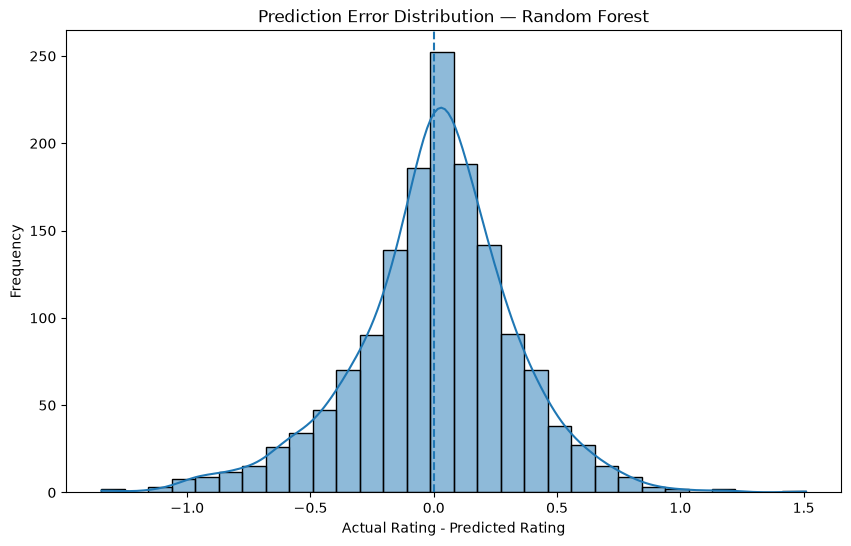

In [190]:
plt.figure(figsize=(10, 6))

sns.histplot(
    prediction_analysis["Error"],
    bins=30,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    f"Prediction Error Distribution — {best_model_name}"
)

plt.xlabel("Actual Rating - Predicted Rating")
plt.ylabel("Frequency")

plt.savefig(
    "../outputs/figures/task1_error_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [191]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_model = random_forest_model.named_steps["model"]

In [192]:
feature_names = rf_preprocessor.get_feature_names_out()

In [193]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(20)

,Feature,Importance
0,num__Votes,0.524111
1,num__Longitude,0.128875
2,num__Latitude,0.106515
3,num__Average Cost for two,0.054927
4,cat__Country Code_1,0.042556
5,cat__Primary Cuisine_North Indian,0.015118
6,cat__Primary Cuisine_American,0.008743
7,cat__Primary Cuisine_Chinese,0.008000
8,cat__Country Code_30,0.007243
9,num__Price range,0.007050


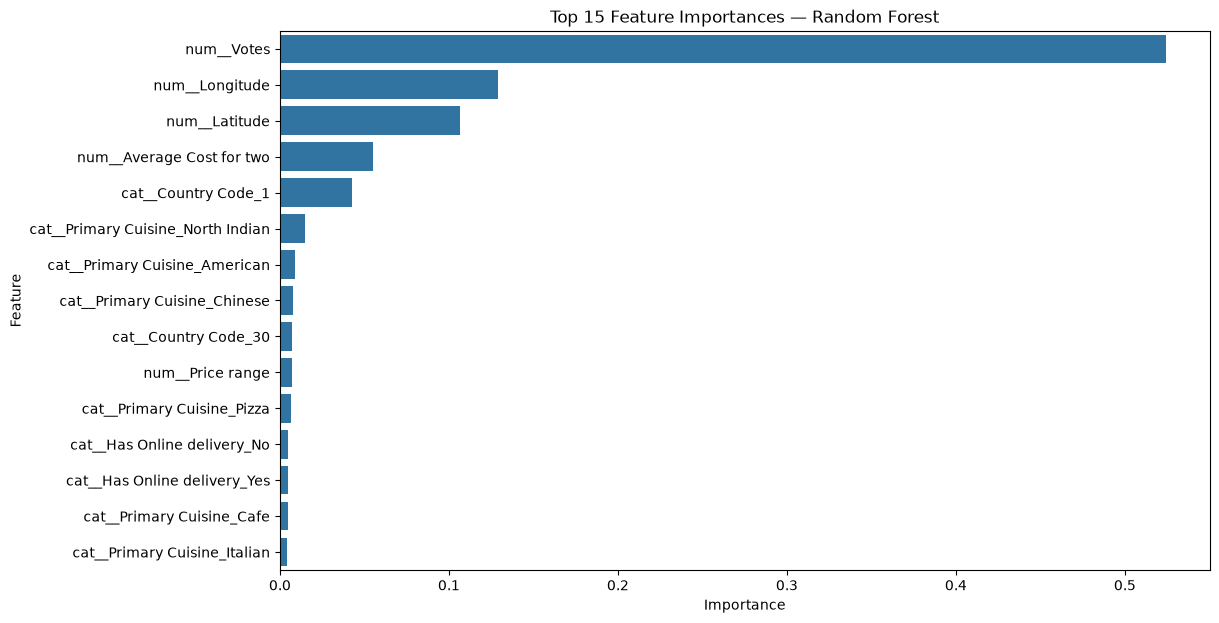

In [194]:
top_features = feature_importance.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Feature Importances — Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig(
    "../outputs/figures/task1_final_feature_importance.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [195]:
feature_importance.to_csv(
    "../outputs/results/task1_final_feature_importance.csv",
    index=False
)

In [196]:
linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

print(
    "Linear Regression"
)
print(
    "Train R²:",
    r2_score(y_train, linear_train_pred)
)
print(
    "Test R²:",
    r2_score(y_test, linear_test_pred)
)

Linear Regression
Train R²: 0.5204344632277881
Test R²: 0.5129657875377254


In [197]:
tree_train_pred = decision_tree_model.predict(X_train)
tree_test_pred = decision_tree_model.predict(X_test)

print(
    "Decision Tree"
)
print(
    "Train R²:",
    r2_score(y_train, tree_train_pred)
)
print(
    "Test R²:",
    r2_score(y_test, tree_test_pred)
)

Decision Tree
Train R²: 0.6922000976579505
Test R²: 0.5332770354911163


In [198]:
rf_train_pred = random_forest_model.predict(X_train)
rf_test_pred = random_forest_model.predict(X_test)

print(
    "Random Forest"
)
print(
    "Train R²:",
    r2_score(y_train, rf_train_pred)
)
print(
    "Test R²:",
    r2_score(y_test, rf_test_pred)
)

Random Forest
Train R²: 0.8646325252695355
Test R²: 0.6522401705646925


In [199]:
overfitting_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Train R²": [
        r2_score(y_train, linear_train_pred),
        r2_score(y_train, tree_train_pred),
        r2_score(y_train, rf_train_pred)
    ],
    "Test R²": [
        r2_score(y_test, linear_test_pred),
        r2_score(y_test, tree_test_pred),
        r2_score(y_test, rf_test_pred)
    ]
})

overfitting_results.round(4)

,Model,Train R²,Test R²
0,Linear Regression,0.5204,0.5130
1,Decision Tree,0.6922,0.5333
2,Random Forest,0.8646,0.6522


In [200]:
overfitting_results.to_csv(
    "../outputs/results/task1_train_test_r2.csv",
    index=False
)

# Task 1 — Final Results

## Models Evaluated

Three regression models were evaluated:

- Linear Regression
- Decision Tree Regression
- Random Forest Regression

## Evaluation Metrics

The models were evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE, MSE, and RMSE indicate lower prediction error,
while a higher R² indicates better explanatory performance.

## Model Selection

The final model was selected based on performance on the
held-out test dataset.

## Error Analysis

Actual versus predicted ratings were analyzed to understand
the prediction quality and identify observations with relatively
large prediction errors.

## Feature Importance

Feature importance from the tree-based model was analyzed to
identify the features that contributed most strongly to the
model's predictions.

## Limitations

The model is based only on the available restaurant attributes
in the dataset. The predictions may be affected by factors that
are not represented in the dataset.

## Conclusion

The restaurant rating prediction problem was treated as a
regression problem. Three regression algorithms were compared
using MAE, MSE, RMSE, and R².

The model with the strongest test performance was selected as
the final model. Error analysis showed where predictions differed
most from actual ratings, while feature importance analysis
identified the variables that contributed most strongly to the
model's predictions.

The analysis provides a machine-learning-based approach for
estimating restaurant ratings from available restaurant,
location, service, and popularity-related attributes.

In [201]:
results_df

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.3036,0.1506,0.3881,0.5130
1,Decision Tree,0.2747,0.1443,0.3799,0.5333
2,Random Forest,0.2425,0.1076,0.3280,0.6522


In [202]:
task1_final_results = results_df.copy()

task1_final_results = task1_final_results.round(4)

task1_final_results

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.3036,0.1506,0.3881,0.5130
1,Decision Tree,0.2747,0.1443,0.3799,0.5333
2,Random Forest,0.2425,0.1076,0.3280,0.6522


In [203]:
task1_final_results.to_csv(
    "../outputs/results/task1_final_results.csv",
    index=False
)

In [204]:
target = "Aggregate rating"

In [205]:
print("Selected features:")
for feature in features:
    print("-", feature)

Selected features:
- Average Cost for two
- Price range
- Votes
- Latitude
- Longitude
- Country Code
- City
- Has Table booking
- Has Online delivery
- Is delivering now
- Primary Cuisine


In [206]:
leakage_columns = [
    "Aggregate rating",
    "Rating text",
    "Rating color"
]

leakage_found = [
    col for col in leakage_columns
    if col in features
]

if leakage_found:
    print("⚠️ Potential data leakage detected:")
    print(leakage_found)
else:
    print("✅ No target leakage columns found in features.")

✅ No target leakage columns found in features.


In [207]:
X = df[features]

In [208]:
print(X.columns.tolist())

['Average Cost for two', 'Price range', 'Votes', 'Latitude', 'Longitude', 'Country Code', 'City', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Primary Cuisine']


In [209]:
for col in leakage_columns:
    print(
        f"{col}:",
        col in X.columns
    )

Aggregate rating: False
Rating text: False
Rating color: False


In [210]:
print("Target column:", target)
print("Target values:")
print(y.head())

Target column: Aggregate rating
Target values:
0    4.8
1    4.5
2    4.4
3    4.9
4    4.8
Name: Aggregate rating, dtype: float64


### Data Leakage Prevention

`Rating text` and `Rating color` were excluded from the
predictive features because they are derived from the
`Aggregate rating`, which is the prediction target.

### Data Leakage Prevention

The target variable for Task 1 is `Aggregate rating`.

The following columns were excluded from the predictive features:

- `Aggregate rating` — this is the target itself.
- `Rating text` — derived from the aggregate rating.
- `Rating color` — derived from the aggregate rating.

Excluding these columns prevents target leakage and ensures that
the model learns from independent restaurant attributes.

In [211]:
print("Target:", target)
print("\nFeatures:")
print(features)

print("\nLeakage check:")

for col in leakage_columns:
    status = "FOUND ❌" if col in features else "NOT FOUND ✅"
    print(f"{col}: {status}")

Target: Aggregate rating

Features:
['Average Cost for two', 'Price range', 'Votes', 'Latitude', 'Longitude', 'Country Code', 'City', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Primary Cuisine']

Leakage check:
Aggregate rating: NOT FOUND ✅
Rating text: NOT FOUND ✅
Rating color: NOT FOUND ✅
